In [2]:
class Bhai_Ka_Logistic_Regression_model:

    def __init__(self,epoch = 1000,lr = 0.05):
        self.epoch = epoch
        self.weights = None
        self.lr = lr
        self.intercept = None
        self.coeff = None
        
    def weight_initilization(self,X):
        self.weights = np.ones(X.shape[1])

    def sigmoid(self,z):
        return 1/(1 + np.exp(-z))
    
    def fit(self,X,y):
        X_new = np.insert(X,0,1,axis=1)
        self.weight_initilization(X_new)
        
        for i in range(self.epoch):
            y_hat = self.sigmoid(np.dot(X_new,self.weights))
            self.weights = self.weights + self.lr*(np.dot(X_new.T,(y-y_hat))/X_new.shape[0])
            
        self.intercept = self.weights[0]
        self.coeff = self.weights[1:]

    def predict(self, X):
        X_new = np.insert(X, 0, 1, axis=1)
        y_hat = self.sigmoid(np.dot(X_new, self.weights))
        
        y_hat = (y_hat >= 0.5).astype(int)
        
        return y_hat

In [4]:
from sklearn.datasets import make_classification
import numpy as np
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=20)

In [5]:
import matplotlib.pyplot as plt

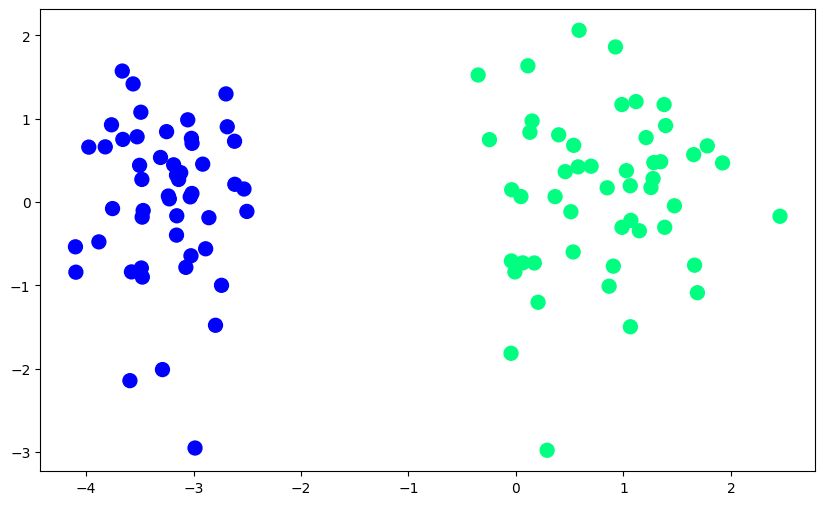

In [6]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [7]:
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression(solver='sag',penalty=None)
lor.fit(X,y)

C:\Users\nikhi\anaconda3\envs\customer_categorizer\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,penalty,None
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'sag'
,max_iter,100
,multi_class,'deprecated'


In [8]:
print(lor.coef_)
print(lor.intercept_)

[[4.79501938 0.20901602]]
[5.76634168]


In [9]:
m_sklearn = -(lor.coef_[0][0] / lor.coef_[0][1])
b_sklearn = -(lor.intercept_ / lor.coef_[0][1])

x_input1 = np.linspace(-3, 3, 100)
y_input1 = m_sklearn * x_input1 + b_sklearn  

In [10]:
model = Bhai_Ka_Logistic_Regression_model(epoch=3200)
model.fit(X,y)

In [11]:
coeff = model.coeff
intercept = model.intercept
print(coeff)
print(intercept)

[3.08801854 0.11061191]
3.230916771394501


In [12]:
m = -(coeff[0]/coeff[1])
b = -(intercept/coeff[1])

x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

(-3.0, 2.0)

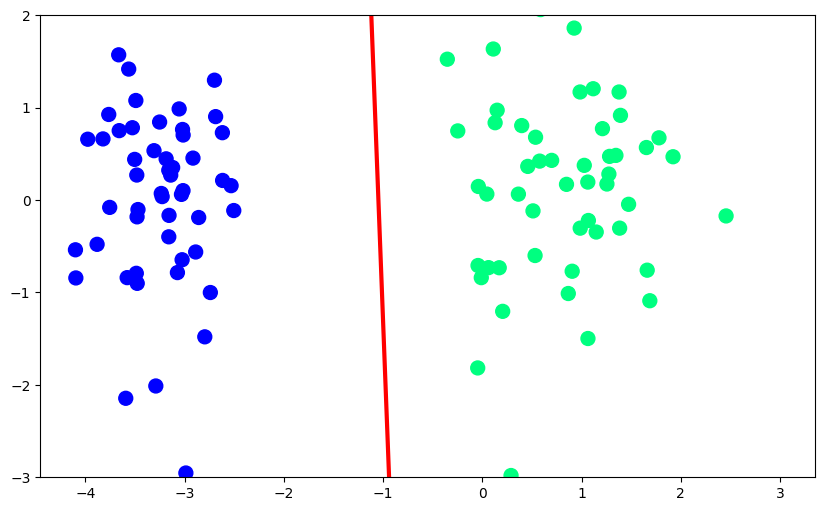

In [13]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

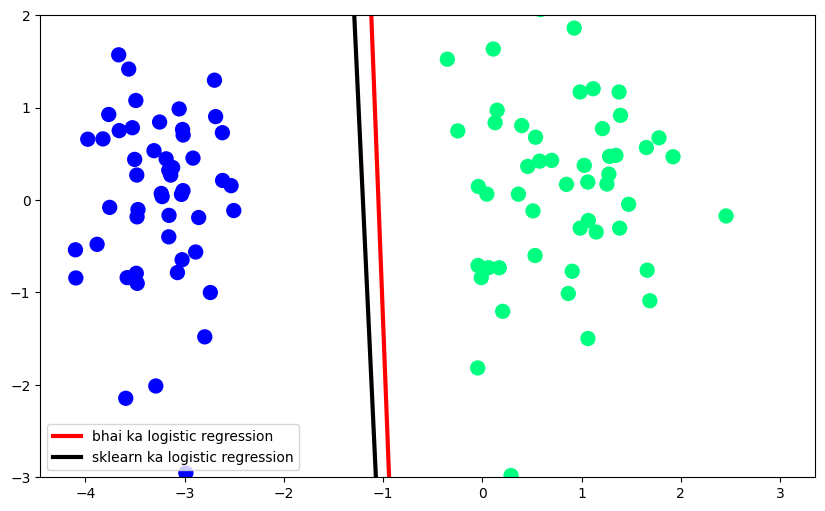

In [14]:
# %matplotlib inline

plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3,label = 'bhai ka logistic regression')
plt.plot(x_input1,y_input1,color='black',linewidth=3,label = 'sklearn ka logistic regression')
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.legend()
plt.ylim(-3,2)
plt.show()